In [ ]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="cafeteria_db"
)

print("Connected!")

In [1]:
print("python is working")

python is working


In [1]:
print("kernel OK")

kernel OK


In [2]:
import pandas as pd
print(pd.__version__)

1.4.1


In [3]:
import pandas as pd

file = r"C:\Users\Sakshi Adhikari\Downloads\Cafeteria Order Data\orders_50k.tsv"

df = pd.read_csv(file, sep="\t")

print(df.shape)
df.head()

(50000, 12)


,id,order_date,branch_id,user_id,sub_total,tax_amount,discount_amount,grand_total,mode_of_transaction,order_through,order_status,is_refunded
0,3216869,2024-04-01 05:30:34,4,12863,25.0,1.19,0.0,25.0,Cash,pos,3,0
1,3216870,2024-04-01 05:33:22,4,12863,17.0,0.00,0.0,17.0,Cash,pos,3,0
2,3216871,2024-04-01 05:32:58,1,457,45.0,2.14,0.0,45.0,QR,pos,3,0
3,3216872,2024-04-01 05:33:21,1,544,30.0,1.43,0.0,30.0,QR,pos,3,0
4,3216873,2024-04-01 05:34:29,1,544,60.0,2.86,0.0,60.0,QR,pos,3,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   50000 non-null  int64  
 1   order_date           50000 non-null  object 
 2   branch_id            50000 non-null  int64  
 3   user_id              50000 non-null  int64  
 4   sub_total            50000 non-null  float64
 5   tax_amount           50000 non-null  float64
 6   discount_amount      10431 non-null  float64
 7   grand_total          50000 non-null  float64
 8   mode_of_transaction  49329 non-null  object 
 9   order_through        50000 non-null  object 
 10  order_status         50000 non-null  int64  
 11  is_refunded          50000 non-null  int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 4.6+ MB


In [5]:
df.isna().sum()

id                         0
order_date                 0
branch_id                  0
user_id                    0
sub_total                  0
tax_amount                 0
discount_amount        39569
grand_total                0
mode_of_transaction      671
order_through              0
order_status               0
is_refunded                0
dtype: int64

In [6]:
df.describe()

,id,branch_id,user_id,sub_total,tax_amount,discount_amount,grand_total,order_status,is_refunded
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,10431.000000,50000.000000,50000.0,50000.0
mean,3.241868e+06,1.706420,9843.996700,66.051240,0.632045,0.001825,64.833857,3.0,0.0
std,1.443390e+04,0.783098,9837.951567,57.067666,2.270964,0.131816,57.479788,0.0,0.0
min,3.216869e+06,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,3.0,0.0
25%,3.229369e+06,1.000000,585.000000,40.000000,0.000000,0.000000,40.000000,3.0,0.0
50%,3.241868e+06,2.000000,5705.000000,50.000000,0.000000,0.000000,50.000000,3.0,0.0
75%,3.254368e+06,2.000000,17414.000000,90.000000,0.000000,0.000000,85.000000,3.0,0.0
max,3.266868e+06,4.000000,31580.000000,5763.000000,74.650000,9.520000,5763.000000,3.0,0.0


In [7]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

num_cols = [
    "sub_total", "tax_amount", "discount_amount",
    "grand_total"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["order_date", "branch_id"])

print("Rows:", len(df))
print("Date range:", df["order_date"].min(), "to", df["order_date"].max())

Rows: 50000
Date range: 2024-04-01 05:30:34 to 2024-04-03 22:39:02


In [8]:
df["date"] = df["order_date"].dt.date
df["hour"] = df["order_date"].dt.hour
df["day_name"] = df["order_date"].dt.day_name()
df["month"] = df["order_date"].dt.to_period("M").astype(str)

df.head()

,id,order_date,branch_id,user_id,sub_total,tax_amount,discount_amount,grand_total,mode_of_transaction,order_through,order_status,is_refunded,date,hour,day_name,month
0,3216869,2024-04-01 05:30:34,4,12863,25.0,1.19,0.0,25.0,Cash,pos,3,0,2024-04-01,5,Monday,2024-04
1,3216870,2024-04-01 05:33:22,4,12863,17.0,0.00,0.0,17.0,Cash,pos,3,0,2024-04-01,5,Monday,2024-04
2,3216871,2024-04-01 05:32:58,1,457,45.0,2.14,0.0,45.0,QR,pos,3,0,2024-04-01,5,Monday,2024-04
3,3216872,2024-04-01 05:33:21,1,544,30.0,1.43,0.0,30.0,QR,pos,3,0,2024-04-01,5,Monday,2024-04
4,3216873,2024-04-01 05:34:29,1,544,60.0,2.86,0.0,60.0,QR,pos,3,0,2024-04-01,5,Monday,2024-04


In [9]:
branch_summary = (
    df.groupby("branch_id")
      .agg(
          orders=("id", "count"),
          revenue=("grand_total", "sum"),
          avg_order_value=("grand_total", "mean")
      )
      .sort_values("orders", ascending=False)
)

branch_summary

,orders,revenue,avg_order_value
branch_id,,,
2,25175,1595168.35,63.363192
1,21443,1470295.50,68.567621
4,3382,176229.00,52.107924


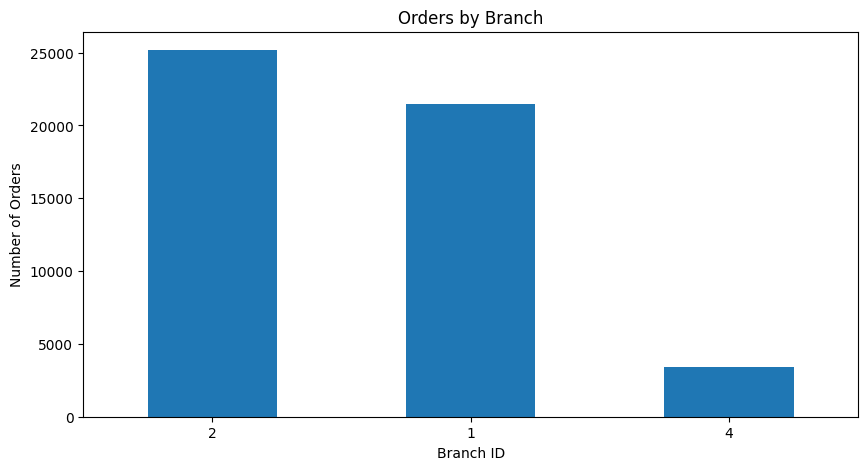

In [10]:
import matplotlib.pyplot as plt

branch_summary["orders"].plot(kind="bar", figsize=(10,5))
plt.title("Orders by Branch")
plt.xlabel("Branch ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [11]:
daily = (
    df.groupby("date")
      .agg(
          orders=("id", "count"),
          revenue=("grand_total", "sum")
      )
)

daily.head()

,orders,revenue
date,,
2024-04-01,12168,745170.20
2024-04-02,20134,1288705.00
2024-04-03,17698,1207817.65


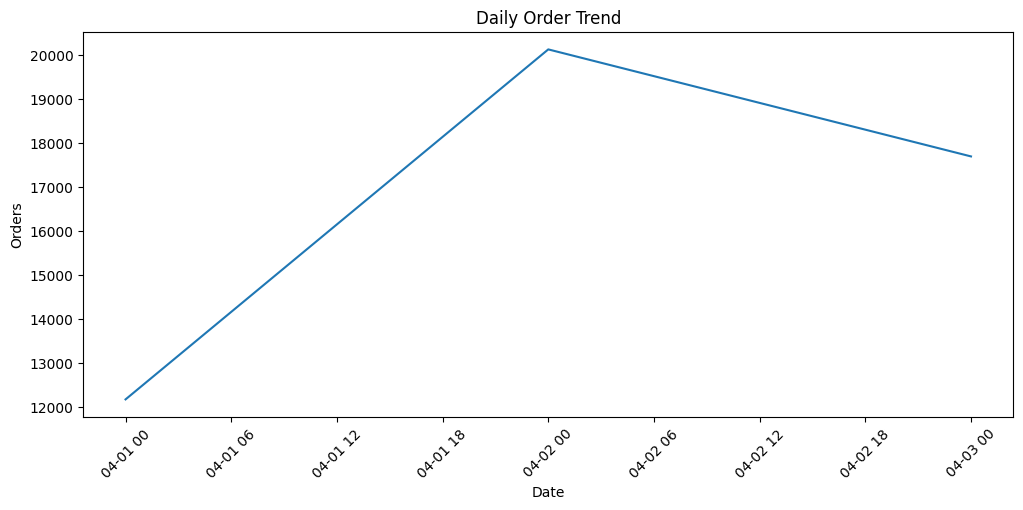

In [12]:
daily["orders"].plot(figsize=(12,5))
plt.title("Daily Order Trend")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

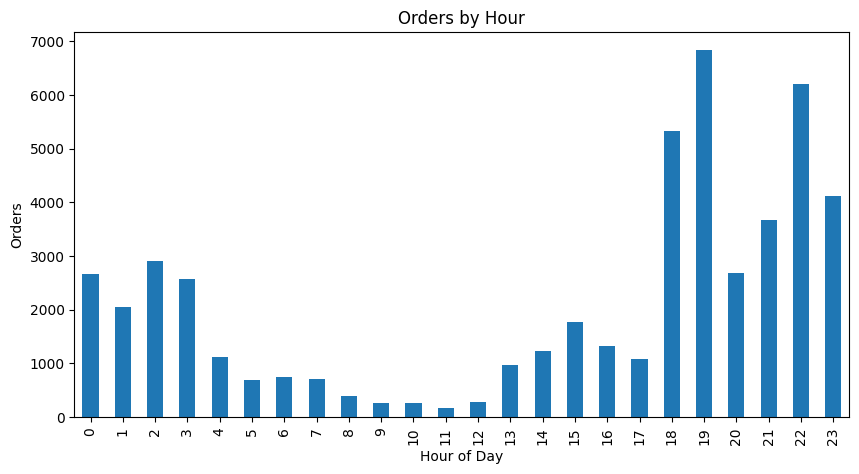

In [13]:
hourly = df.groupby("hour")["id"].count()

hourly.plot(kind="bar", figsize=(10,5))
plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Orders")
plt.show()

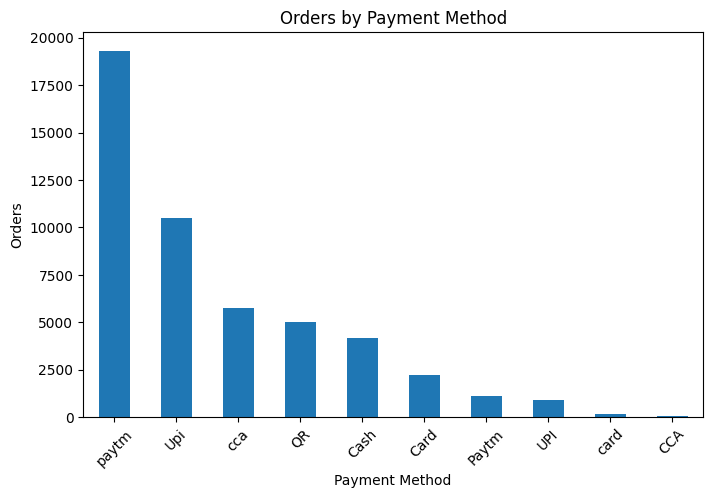

In [14]:
payment = df["mode_of_transaction"].value_counts()

payment.plot(kind="bar", figsize=(8,5))
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

In [20]:
print("First:", df["order_date"].min())
print("Last :", df["order_date"].max())
print("Days :", df["date"].nunique())

First: 2024-04-01 05:30:34
Last : 2024-04-03 22:39:02
Days : 3


In [16]:
print("Branches:", df["branch_id"].nunique())
print(sorted(df["branch_id"].unique()))

Branches: 3
[1, 2, 4]


In [17]:
daily.describe()

,orders,revenue
count,3.000000,3.000000e+00
mean,16666.666667,1.080564e+06
std,4081.914420,2.932620e+05
min,12168.000000,7.451702e+05
25%,14933.000000,9.764939e+05
50%,17698.000000,1.207818e+06
75%,18916.000000,1.248261e+06
max,20134.000000,1.288705e+06


In [18]:
branch_summary

,orders,revenue,avg_order_value
branch_id,,,
2,25175,1595168.35,63.363192
1,21443,1470295.50,68.567621
4,3382,176229.00,52.107924


In [19]:
print(branch_summary)

           orders     revenue  avg_order_value
branch_id                                     
2           25175  1595168.35        63.363192
1           21443  1470295.50        68.567621
4            3382   176229.00        52.107924


In [21]:
branch2 = df[df["branch_id"] == 2].copy()

daily_b2 = (
    branch2.groupby("date")
           .size()
           .reset_index(name="orders")
)

daily_b2["date"] = pd.to_datetime(daily_b2["date"])

print(daily_b2.head())
print(daily_b2.tail())
print("Number of days:", len(daily_b2))

        date  orders
0 2024-04-01    6432
1 2024-04-02    9921
2 2024-04-03    8822
        date  orders
0 2024-04-01    6432
1 2024-04-02    9921
2 2024-04-03    8822
Number of days: 3


In [23]:
sample5 = pd.read_csv("orders_5m.tsv", sep="\t")

print("Rows:", len(sample5))
print("Start:", sample5["order_date"].min())
print("End:", sample5["order_date"].max())

Rows: 50000
Start: 2024-07-30 23:39:27
End: 2024-08-02 02:06:10


In [24]:
sample7 = pd.read_csv(
    r"C:\Users\Sakshi Adhikari\Downloads\Cafeteria Order Data\orders_7m.tsv",
    sep="\t"
)

print("Rows:", len(sample7))
print("Start:", sample7["order_date"].min())
print("End:", sample7["order_date"].max())

Rows: 50000
Start: 2024-12-02 23:03:55
End: 2024-12-04 21:08:36


In [25]:
df_all = pd.concat(
    [df, sample5, sample7],
    ignore_index=True
)

df_all["order_date"] = pd.to_datetime(
    df_all["order_date"],
    errors="coerce"
)

for col in ["sub_total", "tax_amount", "discount_amount", "grand_total"]:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

df_all = df_all.dropna(subset=["order_date", "branch_id"])

print("Total rows:", len(df_all))
print("Date range:", df_all["order_date"].min(), "to", df_all["order_date"].max())

Total rows: 150000
Date range: 2024-04-01 05:30:34 to 2024-12-04 21:08:36


In [26]:
print("Shape:", df_all.shape)

Shape: (150000, 16)


In [36]:
print("Missing values:")
print(df_all.isna().sum())

Missing values:
id                     0
order_date             0
branch_id              0
user_id                0
sub_total              0
tax_amount             0
discount_amount        0
grand_total            0
mode_of_transaction    0
order_through          0
order_status           0
is_refunded            0
date                   0
hour                   0
day_name               0
month                  0
dtype: int64


In [34]:
# Recreate time-based features for the combined dataset
df_all["order_date"] = pd.to_datetime(df_all["order_date"], errors="coerce")

df_all["date"] = df_all["order_date"].dt.date
df_all["hour"] = df_all["order_date"].dt.hour
df_all["day_name"] = df_all["order_date"].dt.day_name()
df_all["month"] = df_all["order_date"].dt.to_period("M").astype(str)

# Handle missing categorical/numeric values
df_all["mode_of_transaction"] = (
    df_all["mode_of_transaction"].fillna("Unknown")
)

df_all["discount_amount"] = (
    df_all["discount_amount"].fillna(0)
)

print(df_all.isna().sum())

id                     0
order_date             0
branch_id              0
user_id                0
sub_total              0
tax_amount             0
discount_amount        0
grand_total            0
mode_of_transaction    0
order_through          0
order_status           0
is_refunded            0
date                   0
hour                   0
day_name               0
month                  0
dtype: int64


In [35]:
print("Rows:", len(df_all))
print("Date range:", df_all["order_date"].min(), "to", df_all["order_date"].max())
print("Branches:", df_all["branch_id"].unique())

Rows: 150000
Date range: 2024-04-01 05:30:34 to 2024-12-04 21:08:36
Branches: [4 1 2 9]


In [29]:
print("Duplicate rows:", df_all.duplicated().sum())

Duplicate rows: 0


In [30]:
print("Order status:")
print(df_all["order_status"].value_counts())

Order status:
3    150000
Name: order_status, dtype: int64


In [31]:
print("Branches:")
print(df_all["branch_id"].value_counts())

Branches:
2    69203
1    60505
4    10265
9    10027
Name: branch_id, dtype: int64


In [32]:
print("Payment modes:")
print(df_all["mode_of_transaction"].value_counts())

Payment modes:
paytm       58776
Upi         27055
cca         15460
Cash        11074
QR          10964
razorpay    10564
Card         5587
UPI          3169
Paytm        2558
card          698
Razorpay      213
CCA           180
Name: mode_of_transaction, dtype: int64


In [33]:
print("Order channels:")
print(df_all["order_through"].value_counts())

Order channels:
mobile app    91453
sok           32512
pos           26035
Name: order_through, dtype: int64


# Branch performance

In [40]:
branch_summary = (
    df_all.groupby("branch_id")
    .agg(
        orders=("id", "count"),
        revenue=("grand_total", "sum"),
        avg_order_value=("grand_total", "mean")
    )
    .sort_values("orders", ascending=False)
)

branch_summary["order_share_%"] = (
    branch_summary["orders"] / branch_summary["orders"].sum() * 100
).round(2)

branch_summary["revenue_share_%"] = (
    branch_summary["revenue"] / branch_summary["revenue"].sum() * 100
).round(2)

branch_summary.round(2)

,orders,revenue,avg_order_value,order_share_%,revenue_share_%
branch_id,,,,,
2,69203,4142620.83,59.86,46.14,44.01
1,60505,4141897.41,68.46,40.34,44.01
4,10265,554565.00,54.02,6.84,5.89
9,10027,572867.35,57.13,6.68,6.09


# monthly trend

In [42]:
monthly = (
    df_all.groupby("month")
    .agg(
        orders=("id", "count"),
        revenue=("grand_total", "sum")
    )
)

monthly["avg_order_value"] = (
    monthly["revenue"] / monthly["orders"]
)

monthly.round(2)

,orders,revenue,avg_order_value
month,,,
2024-04,50000,3241692.85,64.83
2024-07,24258,1605123.95,66.17
2024-08,25742,1704678.40,66.22
2024-12,50000,2860455.39,57.21


# Hourly pattern

In [44]:
hourly = (
    df_all.groupby("hour")
    .agg(
        orders=("id", "count"),
        revenue=("grand_total", "sum")
    )
)

hourly["avg_order_value"] = (
    hourly["revenue"] / hourly["orders"]
)

hourly.round(2)

,orders,revenue,avg_order_value
hour,,,
0,9410,488371.05,51.90
1,7958,582075.95,73.14
2,9919,764983.50,77.12
3,8291,681000.02,82.14
4,4215,297762.65,70.64
5,2261,150746.42,66.67
6,2316,104804.80,45.25
7,2336,106313.92,45.51
8,1557,74994.25,48.17


In [45]:
#peak hours

In [46]:
hourly.sort_values("orders", ascending=False).head(5)

,orders,revenue,avg_order_value
hour,,,
19,18329,1445794.06,78.880139
23,15816,754625.27,47.712776
22,15411,923399.55,59.918211
18,13961,1104042.86,79.080500
2,9919,764983.50,77.123047


# Day of week pattern

In [48]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_pattern = (
    df_all.groupby("day_name")
    .agg(
        orders=("id", "count"),
        revenue=("grand_total", "sum")
    )
    .reindex(day_order)
)

daily_pattern["avg_order_value"] = (
    daily_pattern["revenue"] / daily_pattern["orders"]
)

daily_pattern.round(2)

,orders,revenue,avg_order_value
day_name,,,
Monday,14708.0,837493.30,56.94
Tuesday,48006.0,2855380.86,59.48
Wednesday,61544.0,4014398.03,65.23
Thursday,23016.0,1522457.60,66.15
Friday,2726.0,182220.80,66.85
Saturday,NaN,NaN,NaN
Sunday,NaN,NaN,NaN


# Payment analysis

In [51]:
df_all["payment_clean"] = (
    df_all["mode_of_transaction"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_all["payment_clean"] = df_all["payment_clean"].replace({
    "upi": "UPI",
    "paytm": "Paytm",
    "cca": "CCA",
    "cash": "Cash",
    "qr": "QR",
    "razorpay": "Razorpay",
    "card": "Card",
    "unknown": "Unknown"
})

payment_clean = (
    df_all.groupby("payment_clean")
    .agg(
        orders=("id", "count"),
        revenue=("grand_total", "sum")
    )
    .sort_values("orders", ascending=False)
)

payment_clean["order_share_%"] = (
    payment_clean["orders"] /
    payment_clean["orders"].sum() * 100
).round(2)

payment_clean.round(2)

,orders,revenue,order_share_%
payment_clean,,,
Paytm,61334,3464297.53,40.89
UPI,30224,2429912.00,20.15
CCA,15640,982309.52,10.43
Cash,11074,598371.00,7.38
QR,10964,501271.00,7.31
Razorpay,10777,551955.08,7.18
Card,6285,701193.00,4.19
Unknown,3702,182641.46,2.47


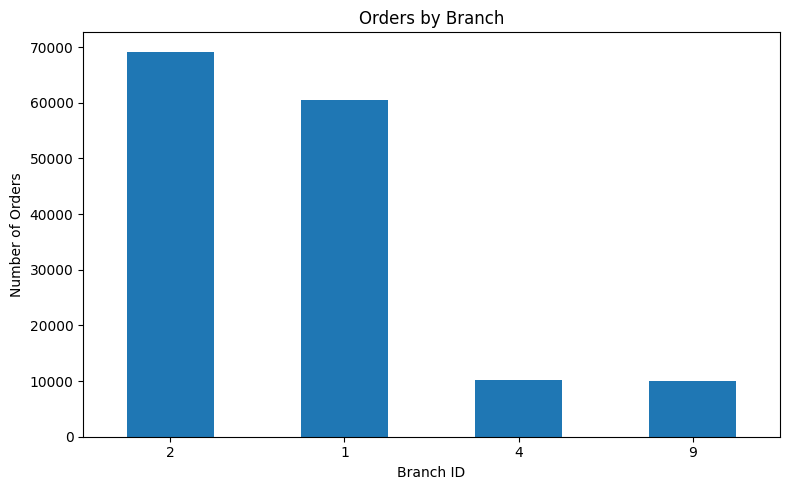

In [52]:
import matplotlib.pyplot as plt

branch_orders = (
    df_all.groupby("branch_id")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
branch_orders.plot(kind="bar")
plt.title("Orders by Branch")
plt.xlabel("Branch ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

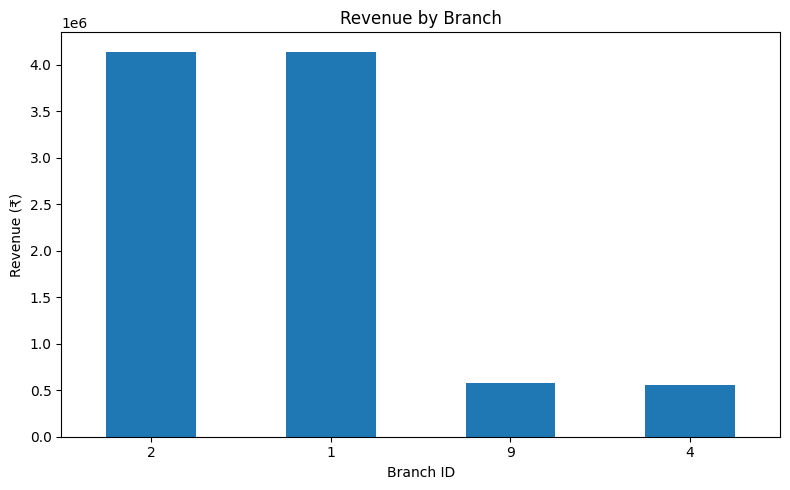

In [53]:
branch_revenue = (
    df_all.groupby("branch_id")["grand_total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
branch_revenue.plot(kind="bar")
plt.title("Revenue by Branch")
plt.xlabel("Branch ID")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

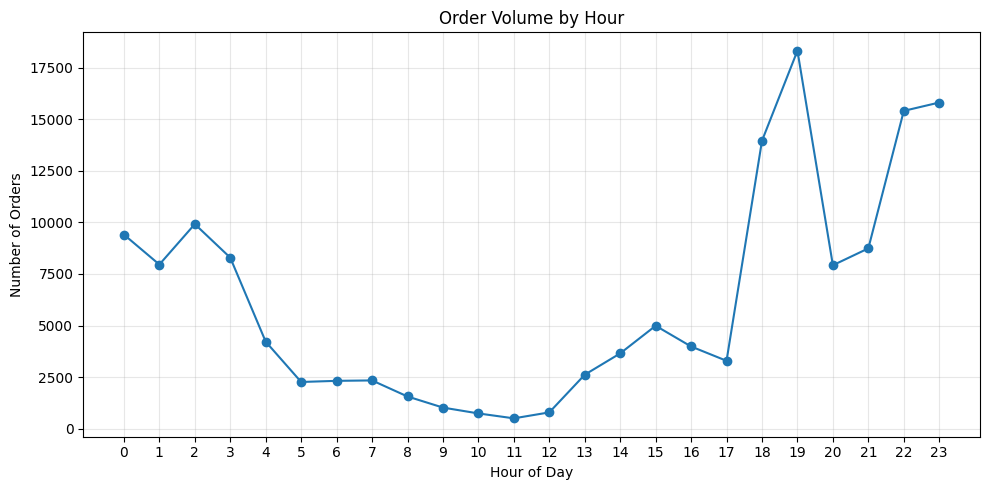

In [54]:
hourly_orders = (
    df_all.groupby("hour")
    .size()
)

plt.figure(figsize=(10,5))
hourly_orders.plot(kind="line", marker="o")
plt.title("Order Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

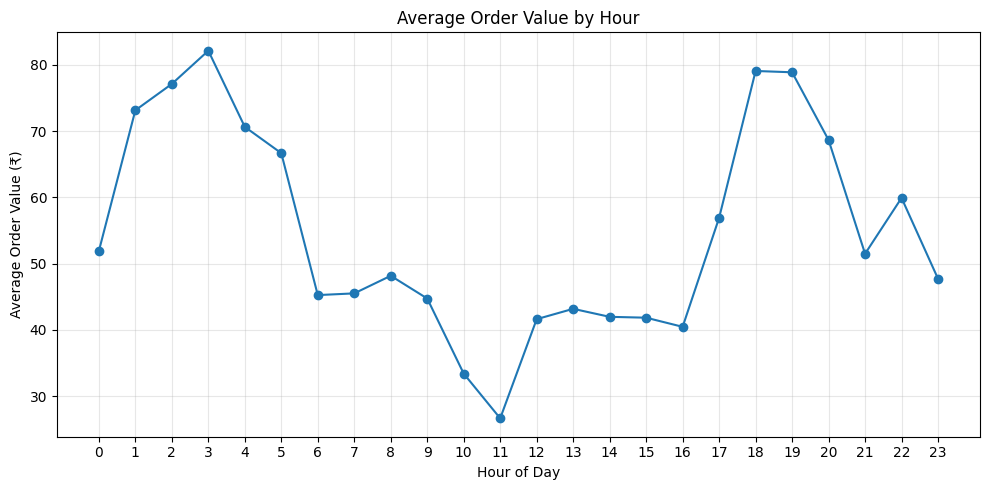

In [55]:
hourly_aov = (
    df_all.groupby("hour")["grand_total"]
    .mean()
)

plt.figure(figsize=(10,5))
hourly_aov.plot(kind="line", marker="o")
plt.title("Average Order Value by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Order Value (₹)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
summary = pd.DataFrame({
    "Metric": [
        "Total extracted orders",
        "Number of branches",
        "Total extracted revenue",
        "Overall average order value",
        "Highest order-volume branch",
        "Highest AOV branch",
        "Peak order hour",
        "Most-used payment method"
    ],
    "Value": [
        f"{len(df_all):,}",
        df_all["branch_id"].nunique(),
        f"₹{df_all['grand_total'].sum():,.2f}",
        f"₹{df_all['grand_total'].mean():,.2f}",
        branch_orders.index[0],
        df_all.groupby("branch_id")["grand_total"].mean().idxmax(),
        f"{hourly_orders.idxmax()}:00",
        payment_clean["orders"].idxmax()
    ]
})

summary

,Metric,Value
0,Total extracted orders,"150,000"
1,Number of branches,4
2,Total extracted revenue,"₹9,411,950.59"
3,Overall average order value,₹62.75
4,Highest order-volume branch,2
5,Highest AOV branch,1
6,Peak order hour,19:00
7,Most-used payment method,Paytm


In [57]:
#order status

In [58]:
status_summary = (
    df_all.groupby("order_status")
    .agg(
        orders=("id", "count"),
        revenue=("grand_total", "sum")
    )
    .sort_values("orders", ascending=False)
)

status_summary["order_share_%"] = (
    status_summary["orders"] /
    status_summary["orders"].sum() * 100
).round(2)

status_summary.round(2)

,orders,revenue,order_share_%
order_status,,,
3,150000,9411950.59,100.0


In [60]:
print(df_all.columns.tolist())

['id', 'order_date', 'branch_id', 'user_id', 'sub_total', 'tax_amount', 'discount_amount', 'grand_total', 'mode_of_transaction', 'order_through', 'order_status', 'is_refunded', 'date', 'hour', 'day_name', 'month', 'payment_clean']


In [61]:
order_through_summary = (
    df_all.groupby("order_through")
    .agg(
        orders=("id", "count"),
        revenue=("grand_total", "sum"),
        avg_order_value=("grand_total", "mean")
    )
    .sort_values("orders", ascending=False)
)

order_through_summary["order_share_%"] = (
    order_through_summary["orders"] /
    order_through_summary["orders"].sum() * 100
).round(2)

order_through_summary.round(2)

,orders,revenue,avg_order_value,order_share_%
order_through,,,,
mobile app,91453,5181203.59,56.65,60.97
sok,32512,2574953.00,79.20,21.67
pos,26035,1655794.00,63.60,17.36
